In [3]:
import random
import time
import warnings
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from braindecode.models import Deep4Net, EEGNet, ShallowFBCSPNet
from mne import Epochs, pick_types
from mne.channels import make_standard_montage
from mne.datasets import eegbci
from mne.decoding import CSP
from mne.io import concatenate_raws, read_raw_edf
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, TensorDataset


warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("ERROR")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 7
DATA_ROOT = Path("/NAS/aniruddham/mne/data")
RUNS = [4, 8, 12]
RESAMPLE_SFREQ = 160.0
EPOCH_WINDOW = (0.0, 4.0)
DEFAULT_CROP_WINDOW = (0.5, 4.0)
DEFAULT_FILTER_BAND = (8.0, 30.0)
MAX_SUBJECTS = None  # set to a small number like 12 for quick iteration
TEST_SIZE = 0.2
VAL_SIZE = 0.2
BATCH_SIZE = 64
MAX_EPOCHS = 12
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EVAL_MODELS = ["CSP + LDA", "FBCSP + LDA", "EEGNet", "ShallowConvNet"]
WINDOW_SWEEP = [(0.5, 2.5), (1.0, 3.0), (0.5, 4.0)]
BAND_SWEEP = [(8.0, 30.0), (8.0, 14.0), (14.0, 30.0), (4.0, 40.0)]
FILTER_BANK_BANDS = [(4.0, 8.0), (8.0, 12.0), (12.0, 16.0), (16.0, 24.0), (24.0, 30.0)]
SENSORIMOTOR_CHANNEL_SETS = {
    "all_channels": None,
    "motor_strip_3": ["C3", "Cz", "C4"],
    "motor_strip_5": ["FC3", "C3", "Cz", "C4", "FC4"],
    "sensorimotor_9": ["FC3", "FCz", "FC4", "C3", "Cz", "C4", "CP3", "CPz", "CP4"],
    "sensorimotor_17": [
        "FC5",
        "FC3",
        "FC1",
        "FCz",
        "FC2",
        "FC4",
        "FC6",
        "C5",
        "C3",
        "C1",
        "Cz",
        "C2",
        "C4",
        "C6",
        "CP3",
        "CPz",
        "CP4",
    ],
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MONTAGE = make_standard_montage("standard_1005")

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def infer_available_subjects(data_root: Path = DATA_ROOT) -> list[int]:
    return sorted(
        int(path.name[1:])
        for path in data_root.glob("S[0-9][0-9][0-9]")
        if path.is_dir()
    )


def local_run_paths(
    subject: int, runs: list[int], data_root: Path = DATA_ROOT
) -> list[Path]:
    subject_name = f"S{subject:03d}"
    return [data_root / subject_name / f"{subject_name}R{run:02d}.edf" for run in runs]


def load_subject_raw(subject: int, runs: list[int] = RUNS) -> mne.io.BaseRaw:
    raw_paths = local_run_paths(subject, runs)
    if not all(path.exists() for path in raw_paths):
        missing = [path.name for path in raw_paths if not path.exists()]
        raise FileNotFoundError(
            f"Missing EDF files for subject {subject:03d}: {missing}"
        )

    raw = concatenate_raws(
        [read_raw_edf(path, preload=True, verbose="ERROR") for path in raw_paths]
    )
    eegbci.standardize(raw)
    raw.pick("eeg")
    raw.set_montage(MONTAGE, match_case=False, on_missing="warn")
    raw.annotations.rename({"T1": "left_hand", "T2": "right_hand"})
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")
    raw.resample(RESAMPLE_SFREQ, verbose="ERROR")
    return raw


def epoch_subject(
    raw: mne.io.BaseRaw,
    crop_window=DEFAULT_CROP_WINDOW,
    filter_band=DEFAULT_FILTER_BAND,
) -> tuple[np.ndarray, np.ndarray, Epochs]:
    raw = raw.copy()
    raw.filter(
        *filter_band, fir_design="firwin", skip_by_annotation="edge", verbose="ERROR"
    )
    events, event_map = mne.events_from_annotations(raw, verbose="ERROR")
    epochs = Epochs(
        raw,
        events,
        event_id={
            "left_hand": event_map["left_hand"],
            "right_hand": event_map["right_hand"],
        },
        tmin=EPOCH_WINDOW[0],
        tmax=EPOCH_WINDOW[1],
        proj=False,
        picks=pick_types(
            raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads"
        ),
        baseline=None,
        preload=True,
        reject_by_annotation=True,
        verbose="ERROR",
    ).crop(*crop_window)

    if len(epochs.times) % 2 != 0:
        epochs.crop(tmin=epochs.tmin, tmax=epochs.times[-2])

    X = epochs.get_data(copy=False).astype(np.float32)
    y = (epochs.events[:, -1] == event_map["right_hand"]).astype(np.int64)
    return X, y, epochs


def build_dataset(
    subjects=None, crop_window=DEFAULT_CROP_WINDOW, filter_band=DEFAULT_FILTER_BAND
) -> dict:
    if subjects is None:
        subjects = infer_available_subjects()
    if MAX_SUBJECTS is not None:
        subjects = subjects[:MAX_SUBJECTS]

    X_parts = []
    y_parts = []
    groups = []
    channel_names = None
    chs_info = None
    example_epochs = None
    kept_subjects = []

    for subject in subjects:
        raw = load_subject_raw(subject)
        X, y, epochs = epoch_subject(
            raw, crop_window=crop_window, filter_band=filter_band
        )
        mean = X.mean(axis=2, keepdims=True)
        std = X.std(axis=2, keepdims=True) + 1e-6
        X = (X - mean) / std

        if channel_names is None:
            channel_names = epochs.ch_names
            chs_info = deepcopy(epochs.info["chs"])
            example_epochs = epochs.copy()
        elif epochs.ch_names != channel_names:
            raise RuntimeError(f"Channel mismatch for subject {subject:03d}")

        X_parts.append(X)
        y_parts.append(y)
        groups.append(np.full(len(y), subject))
        kept_subjects.append(subject)

    return {
        "X": np.concatenate(X_parts, axis=0),
        "y": np.concatenate(y_parts, axis=0),
        "groups": np.concatenate(groups, axis=0),
        "subjects": kept_subjects,
        "channel_names": list(channel_names),
        "chs_info": chs_info,
        "sfreq": float(example_epochs.info["sfreq"]),
        "example_epochs": example_epochs,
        "crop_window": crop_window,
        "filter_band": filter_band,
    }


set_seed()
dataset = build_dataset()
dataset_summary = pd.DataFrame(
    {
        "metric": [
            "subjects_used",
            "epochs_total",
            "left_trials",
            "right_trials",
            "channels",
            "sampling_rate_hz",
            "samples_per_epoch",
            "crop_window_s",
            "filter_band_hz",
        ],
        "value": [
            len(dataset["subjects"]),
            len(dataset["y"]),
            int((dataset["y"] == 0).sum()),
            int((dataset["y"] == 1).sum()),
            len(dataset["channel_names"]),
            dataset["sfreq"],
            dataset["X"].shape[-1],
            str(dataset["crop_window"]),
            str(dataset["filter_band"]),
        ],
    }
)
display(dataset_summary)


,metric,value
0,subjects_used,109
1,epochs_total,4898
2,left_trials,2470
3,right_trials,2428
4,channels,64
5,sampling_rate_hz,160.0
6,samples_per_epoch,560
7,crop_window_s,"(0.5, 4.0)"
8,filter_band_hz,"(8.0, 30.0)"


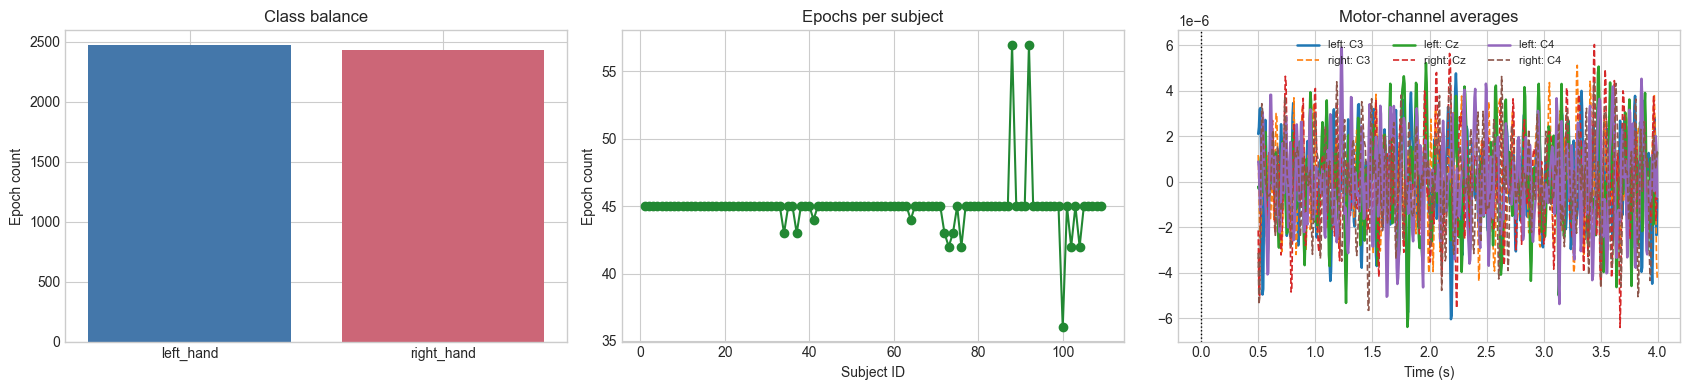

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

class_counts = (
    pd.Series(dataset["y"])
    .map({0: "left_hand", 1: "right_hand"})
    .value_counts()
    .sort_index()
)
axes[0].bar(class_counts.index, class_counts.values, color=["#4477AA", "#CC6677"])
axes[0].set_title("Class balance")
axes[0].set_ylabel("Epoch count")

epochs_per_subject = pd.Series(dataset["groups"]).value_counts().sort_index()
axes[1].plot(
    epochs_per_subject.index,
    epochs_per_subject.values,
    marker="o",
    linewidth=1.5,
    color="#228833",
)
axes[1].set_title("Epochs per subject")
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Epoch count")

motor_channels = [
    ch for ch in ["C3", "Cz", "C4"] if ch in dataset["example_epochs"].ch_names
]
left_evoked = dataset["example_epochs"]["left_hand"].average().pick(motor_channels)
right_evoked = dataset["example_epochs"]["right_hand"].average().pick(motor_channels)
for ch_name in motor_channels:
    idx = left_evoked.ch_names.index(ch_name)
    axes[2].plot(
        left_evoked.times,
        left_evoked.data[idx],
        label=f"left: {ch_name}",
        linewidth=1.8,
    )
    axes[2].plot(
        right_evoked.times,
        right_evoked.data[idx],
        label=f"right: {ch_name}",
        linestyle="--",
        linewidth=1.2,
    )
axes[2].axvline(0.0, color="black", linestyle=":", linewidth=1)
axes[2].set_title("Motor-channel averages")
axes[2].set_xlabel("Time (s)")
axes[2].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


In [6]:
def select_channels(
    X: np.ndarray,
    channel_names: list[str],
    chs_info: list[dict],
    wanted: list[str] | None,
):
    if wanted is None:
        return X, channel_names, chs_info
    name_to_idx = {name: idx for idx, name in enumerate(channel_names)}
    picks = [name_to_idx[ch] for ch in wanted if ch in name_to_idx]
    return (
        X[:, picks, :],
        [channel_names[idx] for idx in picks],
        [deepcopy(chs_info[idx]) for idx in picks],
    )


def make_group_split(groups: np.ndarray, seed: int = SEED) -> dict:
    index = np.arange(len(groups))
    outer = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, groups=groups))
    inner = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=seed + 1)
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), groups=groups[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def make_stratified_split(y: np.ndarray, seed: int = SEED) -> dict:
    index = np.arange(len(y))
    outer = StratifiedShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=seed)
    train_val_idx, test_idx = next(outer.split(index, y))
    inner = StratifiedShuffleSplit(
        n_splits=1, test_size=VAL_SIZE, random_state=seed + 1
    )
    inner_train_rel, inner_val_rel = next(
        inner.split(np.arange(len(train_val_idx)), y[train_val_idx])
    )
    return {
        "train": train_val_idx[inner_train_rel],
        "val": train_val_idx[inner_val_rel],
        "test": test_idx,
    }


def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
    )


def unpack_logits(logits):
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    while logits.ndim > 2 and logits.shape[-1] == 1:
        logits = logits.squeeze(-1)
    if logits.ndim > 2:
        logits = logits.mean(dim=tuple(range(2, logits.ndim)))
    return logits


@torch.no_grad()
def predict_torch(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    preds = []
    for batch_X, _ in loader:
        batch_X = batch_X.to(DEVICE)
        logits = unpack_logits(model(batch_X))
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def build_torch_model(
    model_name: str, n_chans: int, n_times: int, sfreq: float, chs_info: list[dict]
) -> nn.Module:
    common = dict(
        n_chans=n_chans, n_outputs=2, n_times=n_times, sfreq=sfreq, chs_info=chs_info
    )
    if model_name == "EEGNet":
        return EEGNet(**common)
    if model_name == "ShallowConvNet":
        return ShallowFBCSPNet(**common)
    if model_name == "DeepConvNet":
        return Deep4Net(**common)
    raise KeyError(model_name)


def run_csp_lda(X_train, y_train, X_val, y_val, X_test, y_test) -> dict:
    start = time.perf_counter()
    clf = Pipeline(
        [
            (
                "csp",
                CSP(
                    n_components=max(2, min(8, X_train.shape[1])),
                    reg="oas",
                    log=True,
                    norm_trace=False,
                ),
            ),
            ("lda", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
        ]
    )
    clf.fit(X_train, y_train)
    train_time = time.perf_counter() - start
    val_pred = clf.predict(X_val)
    test_pred = clf.predict(X_test)
    return {
        "val_accuracy": (val_pred == y_val).mean(),
        "test_accuracy": (test_pred == y_test).mean(),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "train_time_s": train_time,
        "best_epoch": 1,
        "status": "ok",
    }


def extract_fbcsp_features(
    X_train, y_train, X_other_list, bands=FILTER_BANK_BANDS, sfreq=RESAMPLE_SFREQ
):
    train_features = []
    other_features = [[] for _ in X_other_list]

    for l_freq, h_freq in bands:
        X_train_band = mne.filter.filter_data(
            X_train.copy(),
            sfreq=sfreq,
            l_freq=l_freq,
            h_freq=h_freq,
            verbose="ERROR",
        )
        csp = CSP(
            n_components=max(2, min(4, X_train.shape[1])),
            reg="oas",
            log=True,
            norm_trace=False,
        )
        train_features.append(csp.fit_transform(X_train_band, y_train))

        for idx, X_other in enumerate(X_other_list):
            X_other_band = mne.filter.filter_data(
                X_other.copy(),
                sfreq=sfreq,
                l_freq=l_freq,
                h_freq=h_freq,
                verbose="ERROR",
            )
            other_features[idx].append(csp.transform(X_other_band))

    train_concat = np.concatenate(train_features, axis=1)
    other_concat = [np.concatenate(parts, axis=1) for parts in other_features]
    return train_concat, other_concat


def run_fbcsp_lda(X_train, y_train, X_val, y_val, X_test, y_test, sfreq) -> dict:
    start = time.perf_counter()
    train_features, [val_features, test_features] = extract_fbcsp_features(
        X_train, y_train, [X_val, X_test], bands=FILTER_BANK_BANDS, sfreq=sfreq
    )
    lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    lda.fit(train_features, y_train)
    train_time = time.perf_counter() - start
    val_pred = lda.predict(val_features)
    test_pred = lda.predict(test_features)
    return {
        "val_accuracy": (val_pred == y_val).mean(),
        "test_accuracy": (test_pred == y_test).mean(),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "train_time_s": train_time,
        "best_epoch": 1,
        "status": "ok",
    }


def run_torch_benchmark(
    model_name, X_train, y_train, X_val, y_val, X_test, y_test, sfreq, chs_info
) -> dict:
    set_seed(SEED)
    train_loader = make_loader(X_train, y_train, shuffle=True)
    val_loader = make_loader(X_val, y_val, shuffle=False)
    test_loader = make_loader(X_test, y_test, shuffle=False)

    model = build_torch_model(
        model_name, X_train.shape[1], X_train.shape[2], sfreq, chs_info
    ).to(DEVICE)
    optimizer = optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.CrossEntropyLoss()

    best_state = None
    best_val_accuracy = -np.inf
    best_epoch = 0
    patience_counter = 0
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = unpack_logits(model(batch_X))
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

        val_pred = predict_torch(model, val_loader)
        val_accuracy = (val_pred == y_val).mean()
        if val_accuracy > best_val_accuracy + 1e-4:
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_state = deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

    train_time = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)

    val_pred = predict_torch(model, val_loader)
    test_pred = predict_torch(model, test_loader)
    return {
        "val_accuracy": (val_pred == y_val).mean(),
        "test_accuracy": (test_pred == y_test).mean(),
        "val_balanced_accuracy": balanced_accuracy_score(y_val, val_pred),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, test_pred),
        "train_time_s": train_time,
        "best_epoch": best_epoch,
        "status": "ok",
    }


def benchmark_models(X, y, groups, channel_names, chs_info, sfreq, model_names, split):
    X_train, y_train = X[split["train"]], y[split["train"]]
    X_val, y_val = X[split["val"]], y[split["val"]]
    X_test, y_test = X[split["test"]], y[split["test"]]

    rows = []
    for model_name in model_names:
        print(f"Running {model_name} on {len(channel_names)} channels...")
        try:
            if model_name == "CSP + LDA":
                result = run_csp_lda(X_train, y_train, X_val, y_val, X_test, y_test)
            elif model_name == "FBCSP + LDA":
                result = run_fbcsp_lda(
                    X_train, y_train, X_val, y_val, X_test, y_test, sfreq
                )
            else:
                result = run_torch_benchmark(
                    model_name,
                    X_train,
                    y_train,
                    X_val,
                    y_val,
                    X_test,
                    y_test,
                    sfreq,
                    chs_info,
                )
        except Exception as exc:
            result = {
                "val_accuracy": np.nan,
                "test_accuracy": np.nan,
                "val_balanced_accuracy": np.nan,
                "test_balanced_accuracy": np.nan,
                "train_time_s": np.nan,
                "best_epoch": np.nan,
                "status": f"failed: {type(exc).__name__}: {exc}",
            }

        result.update({"model": model_name, "n_channels": len(channel_names)})
        rows.append(result)

    return pd.DataFrame(rows)


def summarize_min_channels(
    results: pd.DataFrame, tolerance: float = 0.02
) -> pd.DataFrame:
    successful = results.query("status == 'ok'").copy()
    rows = []
    for model_name, model_df in successful.groupby("model"):
        ranked = model_df.sort_values(
            ["n_channels", "test_balanced_accuracy"], ascending=[True, False]
        ).reset_index(drop=True)
        best_score = ranked["test_balanced_accuracy"].max()
        eligible = ranked[
            ranked["test_balanced_accuracy"] >= best_score - tolerance
        ].iloc[0]
        rows.append(
            {
                "model": model_name,
                "best_balanced_accuracy": best_score,
                "min_channels_within_tolerance": int(eligible["n_channels"]),
                "recommended_subset": eligible["subset"],
                "recommended_score": eligible["test_balanced_accuracy"],
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["min_channels_within_tolerance", "recommended_score"], ascending=[True, False]
    )


base_split = make_group_split(dataset["groups"])


Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running ShallowConvNet on 64 channels...


,val_accuracy,test_accuracy,val_balanced_accuracy,test_balanced_accuracy,train_time_s,best_epoch,status,model,n_channels
2,0.664604,0.583418,0.662576,0.582061,17.532339,11.0,ok,EEGNet,64
3,0.653465,0.558140,0.655434,0.559693,3.889129,7.0,ok,ShallowConvNet,64
0,0.587871,0.533873,0.587977,0.533916,24.171446,1.0,ok,CSP + LDA,64
1,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64


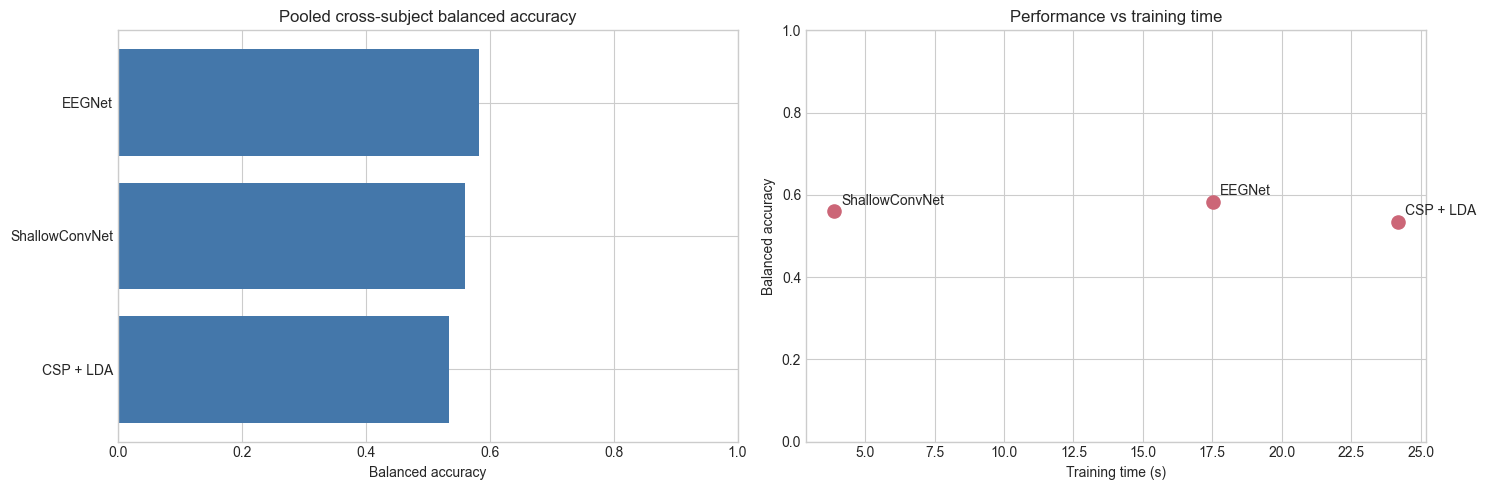

In [7]:
pooled_results = benchmark_models(
    X=dataset["X"],
    y=dataset["y"],
    groups=dataset["groups"],
    channel_names=dataset["channel_names"],
    chs_info=dataset["chs_info"],
    sfreq=dataset["sfreq"],
    model_names=EVAL_MODELS,
    split=base_split,
)

display(pooled_results.sort_values("test_balanced_accuracy", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ranked = pooled_results.query("status == 'ok'").sort_values(
    "test_balanced_accuracy", ascending=True
)
axes[0].barh(ranked["model"], ranked["test_balanced_accuracy"], color="#4477AA")
axes[0].set_title("Pooled cross-subject balanced accuracy")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_xlim(0.0, 1.0)

axes[1].scatter(
    ranked["train_time_s"], ranked["test_balanced_accuracy"], s=90, color="#CC6677"
)
for _, row in ranked.iterrows():
    axes[1].annotate(
        row["model"],
        (row["train_time_s"], row["test_balanced_accuracy"]),
        xytext=(5, 5),
        textcoords="offset points",
    )
axes[1].set_title("Performance vs training time")
axes[1].set_xlabel("Training time (s)")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()


,val_accuracy,test_accuracy,val_balanced_accuracy,test_balanced_accuracy,train_time_s,best_epoch,status,subject
6,1.000,1.000000,1.000,1.0,0.695807,1,ok,7
28,1.000,1.000000,1.000,1.0,0.409967,1,ok,29
84,1.000,1.000000,1.000,1.0,0.570405,1,ok,85
61,0.875,1.000000,0.875,1.0,0.325203,1,ok,62
53,0.750,1.000000,0.750,1.0,0.643669,1,ok,54
83,0.625,1.000000,0.625,1.0,0.582006,1,ok,84
93,0.875,1.000000,0.875,1.0,0.711953,1,ok,94
51,1.000,0.888889,1.000,0.9,0.557626,1,ok,52
55,0.750,0.888889,0.750,0.9,0.383876,1,ok,56
47,0.625,0.888889,0.625,0.9,0.615790,1,ok,48


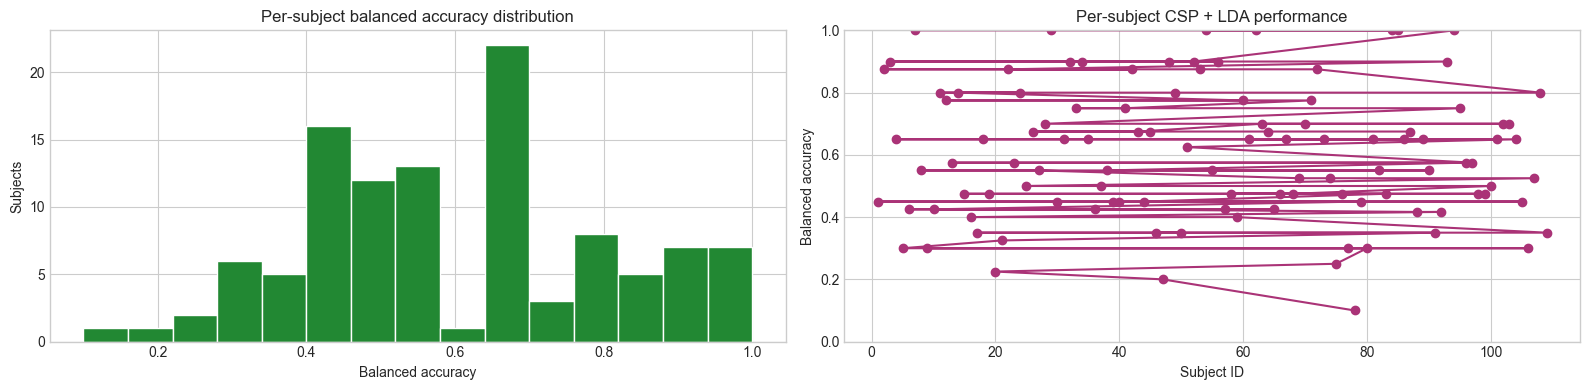

,setting,balanced_accuracy
0,pooled_cross_subject,0.533916
1,within_subject_mean,0.603287
2,within_subject_median,0.575000


In [8]:
within_subject_rows = []
per_subject_model = "CSP + LDA"

for subject in dataset["subjects"]:
    subject_mask = dataset["groups"] == subject
    X_sub = dataset["X"][subject_mask]
    y_sub = dataset["y"][subject_mask]

    if len(np.unique(y_sub)) < 2 or len(y_sub) < 20:
        continue

    split = make_stratified_split(y_sub)
    result = run_csp_lda(
        X_sub[split["train"]],
        y_sub[split["train"]],
        X_sub[split["val"]],
        y_sub[split["val"]],
        X_sub[split["test"]],
        y_sub[split["test"]],
    )
    result["subject"] = subject
    within_subject_rows.append(result)

within_subject_df = pd.DataFrame(within_subject_rows).sort_values(
    "test_balanced_accuracy", ascending=False
)
display(within_subject_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].hist(
    within_subject_df["test_balanced_accuracy"],
    bins=15,
    color="#228833",
    edgecolor="white",
)
axes[0].set_title("Per-subject balanced accuracy distribution")
axes[0].set_xlabel("Balanced accuracy")
axes[0].set_ylabel("Subjects")

axes[1].plot(
    within_subject_df["subject"],
    within_subject_df["test_balanced_accuracy"],
    marker="o",
    linewidth=1.5,
    color="#AA3377",
)
axes[1].set_title("Per-subject CSP + LDA performance")
axes[1].set_xlabel("Subject ID")
axes[1].set_ylabel("Balanced accuracy")
axes[1].set_ylim(0.0, 1.0)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame(
    {
        "setting": [
            "pooled_cross_subject",
            "within_subject_mean",
            "within_subject_median",
        ],
        "balanced_accuracy": [
            float(
                pooled_results.query("model == 'CSP + LDA'")[
                    "test_balanced_accuracy"
                ].iloc[0]
            ),
            within_subject_df["test_balanced_accuracy"].mean(),
            within_subject_df["test_balanced_accuracy"].median(),
        ],
    }
)
display(comparison_df)


Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running ShallowConvNet on 64 channels...
Running CSP + LDA on 3 channels...
Running FBCSP + LDA on 3 channels...
Running EEGNet on 3 channels...
Running ShallowConvNet on 3 channels...
Running CSP + LDA on 5 channels...
Running FBCSP + LDA on 5 channels...
Running EEGNet on 5 channels...
Running ShallowConvNet on 5 channels...
Running CSP + LDA on 9 channels...
Running FBCSP + LDA on 9 channels...
Running EEGNet on 9 channels...
Running ShallowConvNet on 9 channels...
Running CSP + LDA on 17 channels...
Running FBCSP + LDA on 17 channels...
Running EEGNet on 17 channels...
Running ShallowConvNet on 17 channels...


,val_accuracy,test_accuracy,val_balanced_accuracy,test_balanced_accuracy,train_time_s,best_epoch,status,model,n_channels,subset,subset_channels
4,0.555693,0.518706,0.554844,0.519006,0.308807,1.0,ok,CSP + LDA,3,motor_strip_3,"C3, Cz, C4"
8,0.577970,0.530839,0.578166,0.531231,0.544150,1.0,ok,CSP + LDA,5,motor_strip_5,"FC3, C3, Cz, C4, FC4"
12,0.592822,0.503539,0.591886,0.503804,0.939734,1.0,ok,CSP + LDA,9,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
16,0.608911,0.546006,0.607595,0.545781,1.733741,1.0,ok,CSP + LDA,17,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
0,0.587871,0.533873,0.587977,0.533916,97.939225,1.0,ok,CSP + LDA,64,all_channels,all_channels
6,0.634901,0.558140,0.635197,0.559806,4.115573,12.0,ok,EEGNet,3,motor_strip_3,"C3, Cz, C4"
10,0.618812,0.538928,0.618631,0.539186,3.787494,9.0,ok,EEGNet,5,motor_strip_5,"FC3, C3, Cz, C4, FC4"
14,0.665842,0.561173,0.664473,0.560781,4.638164,9.0,ok,EEGNet,9,sensorimotor_9,"FC3, FCz, FC4, C3, Cz, C4, CP3, CPz, CP4"
18,0.672030,0.587462,0.671505,0.587996,4.105952,12.0,ok,EEGNet,17,sensorimotor_17,"FC5, FC3, FC1, FCz, FC2, FC4, FC6, C5, C3, C1,..."
2,0.660891,0.579373,0.658633,0.577679,14.240494,11.0,ok,EEGNet,64,all_channels,all_channels


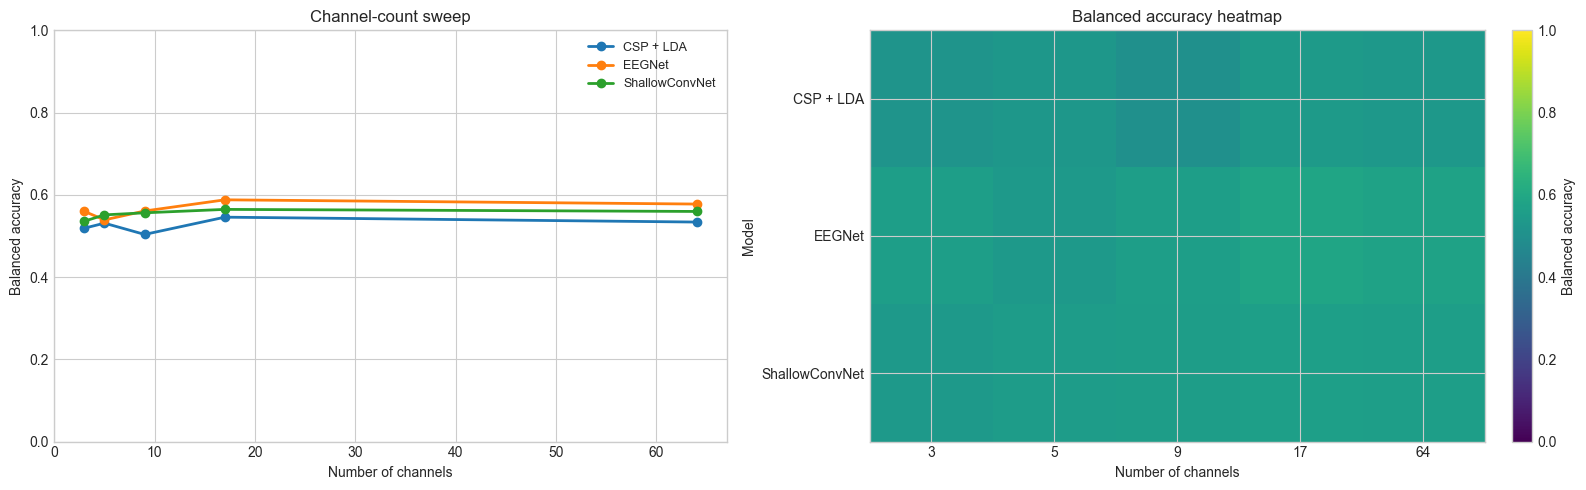

,model,best_balanced_accuracy,min_channels_within_tolerance,recommended_subset,recommended_score
2,ShallowConvNet,0.564714,5,motor_strip_5,0.551376
0,CSP + LDA,0.545781,5,motor_strip_5,0.531231
1,EEGNet,0.587996,17,sensorimotor_17,0.587996


In [9]:
channel_rows = []
for subset_name, subset_channels in SENSORIMOTOR_CHANNEL_SETS.items():
    X_subset, names_subset, chs_subset = select_channels(
        dataset["X"],
        dataset["channel_names"],
        dataset["chs_info"],
        subset_channels,
    )
    subset_results = benchmark_models(
        X=X_subset,
        y=dataset["y"],
        groups=dataset["groups"],
        channel_names=names_subset,
        chs_info=chs_subset,
        sfreq=dataset["sfreq"],
        model_names=EVAL_MODELS,
        split=base_split,
    )
    subset_results["subset"] = subset_name
    subset_results["subset_channels"] = (
        "all_channels" if subset_channels is None else ", ".join(names_subset)
    )
    channel_rows.append(subset_results)

channel_results = pd.concat(channel_rows, ignore_index=True)
display(
    channel_results.sort_values(
        ["model", "n_channels", "test_balanced_accuracy"], ascending=[True, True, False]
    )
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for model_name, model_df in channel_results.query("status == 'ok'").groupby("model"):
    model_df = model_df.sort_values("n_channels")
    axes[0].plot(
        model_df["n_channels"],
        model_df["test_balanced_accuracy"],
        marker="o",
        linewidth=2,
        label=model_name,
    )
axes[0].set_title("Channel-count sweep")
axes[0].set_xlabel("Number of channels")
axes[0].set_ylabel("Balanced accuracy")
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(fontsize=9)

pivot = (
    channel_results.query("status == 'ok'")
    .pivot_table(
        index="model",
        columns="n_channels",
        values="test_balanced_accuracy",
        aggfunc="max",
    )
    .sort_index()
    .sort_index(axis=1)
)
im = axes[1].imshow(pivot.values, aspect="auto", cmap="viridis", vmin=0.0, vmax=1.0)
axes[1].set_title("Balanced accuracy heatmap")
axes[1].set_xlabel("Number of channels")
axes[1].set_ylabel("Model")
axes[1].set_xticks(np.arange(len(pivot.columns)))
axes[1].set_xticklabels(pivot.columns.astype(int))
axes[1].set_yticks(np.arange(len(pivot.index)))
axes[1].set_yticklabels(pivot.index)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Balanced accuracy")

plt.tight_layout()
plt.show()

min_channel_summary = summarize_min_channels(channel_results)
display(min_channel_summary)


Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...


,val_accuracy,test_accuracy,val_balanced_accuracy,test_balanced_accuracy,train_time_s,best_epoch,status,model,n_channels,crop_window,window_length_s
0,0.580446,0.534884,0.580274,0.535029,120.818639,1.0,ok,CSP + LDA,64,"(0.5, 2.5)",2.0
6,0.587871,0.533873,0.587977,0.533916,59.790486,1.0,ok,CSP + LDA,64,"(0.5, 4.0)",3.5
3,0.584158,0.531850,0.582685,0.531601,40.382595,1.0,ok,CSP + LDA,64,"(1.0, 3.0)",2.0
2,0.649752,0.575329,0.649224,0.575838,6.638002,9.0,ok,EEGNet,64,"(0.5, 2.5)",2.0
8,0.659653,0.570273,0.657441,0.568724,15.874714,8.0,ok,EEGNet,64,"(0.5, 4.0)",3.5
5,0.617574,0.543984,0.615019,0.542926,6.748727,12.0,ok,EEGNet,64,"(1.0, 3.0)",2.0
1,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64,"(0.5, 2.5)",2.0
4,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64,"(1.0, 3.0)",2.0
7,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64,"(0.5, 4.0)",3.5


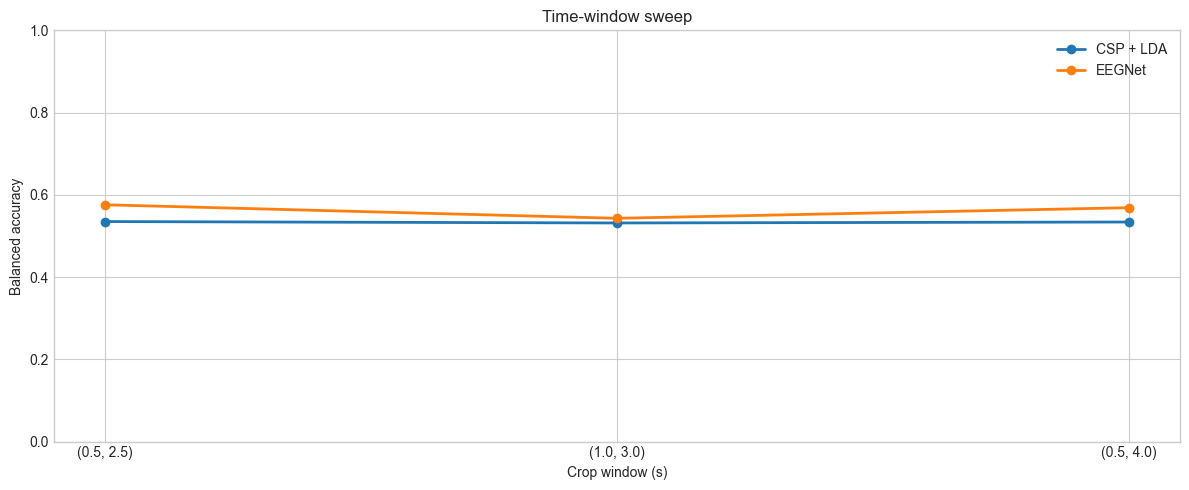

In [10]:
window_rows = []
for crop_window in WINDOW_SWEEP:
    dataset_window = build_dataset(
        crop_window=crop_window, filter_band=DEFAULT_FILTER_BAND
    )
    split_window = make_group_split(dataset_window["groups"])
    results_window = benchmark_models(
        X=dataset_window["X"],
        y=dataset_window["y"],
        groups=dataset_window["groups"],
        channel_names=dataset_window["channel_names"],
        chs_info=dataset_window["chs_info"],
        sfreq=dataset_window["sfreq"],
        model_names=["CSP + LDA", "FBCSP + LDA", "EEGNet"],
        split=split_window,
    )
    results_window["crop_window"] = str(crop_window)
    results_window["window_length_s"] = crop_window[1] - crop_window[0]
    window_rows.append(results_window)

window_results = pd.concat(window_rows, ignore_index=True)
display(
    window_results.sort_values(
        ["model", "test_balanced_accuracy"], ascending=[True, False]
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in window_results.query("status == 'ok'").groupby("model"):
    ax.plot(
        model_df["crop_window"],
        model_df["test_balanced_accuracy"],
        marker="o",
        linewidth=2,
        label=model_name,
    )
ax.set_title("Time-window sweep")
ax.set_xlabel("Crop window (s)")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...
Running CSP + LDA on 64 channels...
Running FBCSP + LDA on 64 channels...
Running EEGNet on 64 channels...


,val_accuracy,test_accuracy,val_balanced_accuracy,test_balanced_accuracy,train_time_s,best_epoch,status,model,n_channels,band
9,0.591584,0.572295,0.590480,0.571759,152.374273,1.0,ok,CSP + LDA,64,4.0-40.0 Hz
6,0.545792,0.552073,0.545033,0.552186,123.438892,1.0,ok,CSP + LDA,64,14.0-30.0 Hz
0,0.587871,0.533873,0.587977,0.533916,65.630231,1.0,ok,CSP + LDA,64,8.0-30.0 Hz
3,0.602723,0.524772,0.602126,0.524534,122.257187,1.0,ok,CSP + LDA,64,8.0-14.0 Hz
2,0.660891,0.580384,0.658817,0.578926,13.944120,11.0,ok,EEGNet,64,8.0-30.0 Hz
5,0.658416,0.578362,0.657444,0.578434,10.042462,5.0,ok,EEGNet,64,8.0-14.0 Hz
11,0.672030,0.577351,0.671780,0.578356,14.774534,12.0,ok,EEGNet,64,4.0-40.0 Hz
8,0.634901,0.579373,0.633114,0.578061,12.922046,12.0,ok,EEGNet,64,14.0-30.0 Hz
1,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64,8.0-30.0 Hz
4,NaN,NaN,NaN,NaN,NaN,NaN,failed: ValueError: Data to be filtered must b...,FBCSP + LDA,64,8.0-14.0 Hz


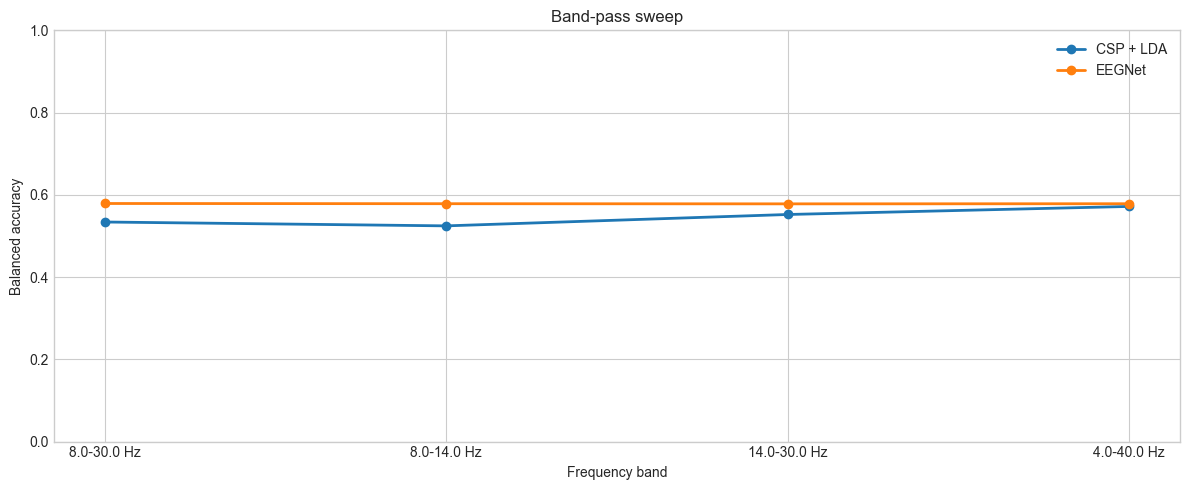

In [11]:
band_rows = []
for band in BAND_SWEEP:
    dataset_band = build_dataset(crop_window=DEFAULT_CROP_WINDOW, filter_band=band)
    split_band = make_group_split(dataset_band["groups"])
    results_band = benchmark_models(
        X=dataset_band["X"],
        y=dataset_band["y"],
        groups=dataset_band["groups"],
        channel_names=dataset_band["channel_names"],
        chs_info=dataset_band["chs_info"],
        sfreq=dataset_band["sfreq"],
        model_names=["CSP + LDA", "FBCSP + LDA", "EEGNet"],
        split=split_band,
    )
    results_band["band"] = f"{band[0]:.1f}-{band[1]:.1f} Hz"
    band_rows.append(results_band)

band_results = pd.concat(band_rows, ignore_index=True)
display(
    band_results.sort_values(
        ["model", "test_balanced_accuracy"], ascending=[True, False]
    )
)

fig, ax = plt.subplots(figsize=(12, 5))
for model_name, model_df in band_results.query("status == 'ok'").groupby("model"):
    ax.plot(
        model_df["band"],
        model_df["test_balanced_accuracy"],
        marker="o",
        linewidth=2,
        label=model_name,
    )
ax.set_title("Band-pass sweep")
ax.set_xlabel("Frequency band")
ax.set_ylabel("Balanced accuracy")
ax.set_ylim(0.0, 1.0)
ax.legend()
plt.tight_layout()
plt.show()


The key questions this notebook answers are:

- Is the main limitation cross-subject transfer rather than the model itself?
- Do fewer motor-relevant channels help more than using all `64` channels?
- Is there a narrower time window or frequency band that improves separability?
- Does filter-bank CSP outperform plain CSP and compact deep baselines?

Use the result tables above to decide which configuration should be promoted back into the main benchmark notebook.
